<a href="https://colab.research.google.com/github/Sibitenda/Masters_MIS/blob/main/Data%20Analysis%20and%20Visualisation/week3_ML/credit_card_R.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Credit Card Fraud Detection (R) - Google Colab Notebook
**Dataset:** Kaggle 'Credit Card Fraud Detection' (`creditcard.csv`)

This notebook is a complete end-to-end R translation of a common Python workflow: EDA → Preprocessing (SMOTE) → Feature Engineering → Dimensionality Reduction (PCA, UMAP) → Modeling (Logistic Regression, Decision Tree, Random Forest) → Evaluation (Stratified CV, ROC, PR curves) → Interpretation & ethical considerations.

**How to run in Google Colab:**
1. Open a new Colab notebook and in the menu choose Runtime → Change runtime type → set 'R' as the language (or use an R notebook environment).
2. Upload `creditcard.csv` to the Colab environment (same folder as the notebook), or change `data_path` in the first code cell to the file location.
3. Run cells sequentially. Each section is modular so you can inspect intermediate outputs.


In [1]:
# Run this in a code cell
!apt-get install -y r-base
%load_ext rpy2.ipython

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
r-base is already the newest version (4.5.1-1.2204.0).
0 upgraded, 0 newly installed, 0 to remove and 35 not upgraded.


In [2]:
%%R
# ==== Cell 0: Setup & Libraries ====
# Install missing packages (uncomment if running in fresh environment)
req_pkgs <- c('tidyverse','data.table','skimr','moments','ggcorrplot','patchwork',
              'tidymodels','themis','ranger','vip','uwot','doParallel')
new_pkgs <- setdiff(req_pkgs, rownames(installed.packages()))
if(length(new_pkgs)) install.packages(new_pkgs, dependencies = TRUE)

# Load libraries
invisible(lapply(req_pkgs, library, character.only = TRUE))

# Set seed and parallel backend
set.seed(123)
if(!foreach::getDoParRegistered()) doParallel::registerDoParallel()

# Short description: this cell ensures the required packages are available and loaded.


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
also installing the dependencies ‘shape’, ‘future.apply’, ‘numDeriv’, ‘progressr’, ‘SQUAREM’, ‘TH.data’, ‘diagram’, ‘lava’, ‘listenv’, ‘libcoin’, ‘matrixStats’, ‘multcomp’, ‘lazyeval’, ‘V8’, ‘litedown’, ‘reactR’, ‘prodlim’, ‘future’, ‘warp’, ‘lhs’, ‘mvtnorm’, ‘modeltools’, ‘strucchange’, ‘coin’, ‘zoo’, ‘sandwich’, ‘flock’, ‘parallelly’, ‘RhpcBLASctl’, ‘ff’, ‘proxy’, ‘extrafontdb’, ‘Rttf2pt1’, ‘plyr’, ‘hunspell’, ‘rex’, ‘bigD’, ‘bitops’, ‘juicyjuice’, ‘markdown’, ‘reactable’, ‘DiceDesign’, ‘sfd’, ‘sparsevctrs’, ‘globals’, ‘clock’, ‘ipred’, ‘timeDate’, ‘furrr’, ‘slider’, ‘GPfit’, ‘modelenv’, ‘crosstalk’, ‘RcppArmadillo’, ‘measures’, ‘party’, ‘BH’, ‘sitmo’, ‘bigassertr’, ‘bigparallelr’, ‘cowplot’, ‘rmio’, ‘e1071’, ‘ModelMetrics’, ‘pROC’, ‘extrafont’, ‘reshape2’, ‘spelling’, ‘vdiffr’, ‘gridGraphics’, ‘gridExtra’, ‘covr’, ‘png’, ‘gt’, ‘dials’, ‘hardhat’, ‘infer’, ‘modeldata’, ‘parsnip’, ‘recipes’, ‘rsample’, 

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
%%R
# ==== Cell 1: Load Data & Quick Check ====
data_path <- '/content/drive/MyDrive/Colab Notebooks/creditcard.csv'  # Update if needed
raw <- readr::read_csv(data_path, show_col_types = FALSE)
raw <- raw %>% mutate(Class = factor(Class, levels = c(0,1), labels = c('non_fraud','fraud')))

# Quick checks
glimpse(raw)
skimr::skim(raw)


Rows: 3,972
Columns: 31
$ Time   <dbl> 0, 0, 1, 1, 2, 2, 4, 7, 7, 9, 10, 10, 10, 11, 12, 12, 12, 13, 1…
$ V1     <dbl> -1.3598071, 1.1918571, -1.3583541, -0.9662717, -1.1582331, -0.4…
$ V2     <dbl> -0.07278117, 0.26615071, -1.34016307, -0.18522601, 0.87773675, …
$ V3     <dbl> 2.53634674, 0.16648011, 1.77320934, 1.79299334, 1.54871785, 1.1…
$ V4     <dbl> 1.37815522, 0.44815408, 0.37977959, -0.86329128, 0.40303393, -0…
$ V5     <dbl> -0.33832077, 0.06001765, -0.50319813, -0.01030888, -0.40719338,…
$ V6     <dbl> 0.46238778, -0.08236081, 1.80049938, 1.24720317, 0.09592146, -0…
$ V7     <dbl> 0.239598554, -0.078802983, 0.791460956, 0.237608940, 0.59294074…
$ V8     <dbl> 0.098697901, 0.085101655, 0.247675787, 0.377435875, -0.27053267…
$ V9     <dbl> 0.3637870, -0.2554251, -1.5146543, -1.3870241, 0.8177393, -0.56…
$ V10    <dbl> 0.09079417, -0.16697441, 0.20764287, -0.05495192, 0.75307443, -…
$ V11    <dbl> -0.55159953, 1.61272666, 0.62450146, -0.22648726, -0.82284288, …
$ V12    <dbl> -

## Step 2 — First EDA (Raw Data)
Compute descriptive statistics for transaction amounts and visualize distributions.

In [6]:
%%R
# ---- 2a: Descriptive stats ----
eda_amount_stats <- raw %>%
  group_by(Class) %>%
  summarise(n = n(),
            mean = mean(Amount, na.rm = TRUE),
            variance = var(Amount, na.rm = TRUE),
            skewness = moments::skewness(Amount, na.rm = TRUE),
            kurtosis = moments::kurtosis(Amount, na.rm = TRUE)) %>%
  ungroup()
eda_amount_stats


# A tibble: 2 × 6
  Class         n  mean variance skewness kurtosis
  <fct>     <int> <dbl>    <dbl>    <dbl>    <dbl>
1 non_fraud  3970  64.9   45630.     17.0     484.
2 fraud         2 264.   139920.      0         1 


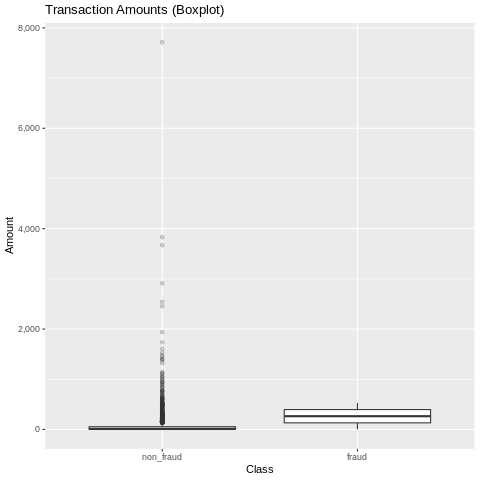

In [7]:
%%R
# ---- 2b: Histograms & Boxplots ----
plt_hist <- ggplot(raw, aes(x = Amount)) +
  geom_histogram(bins = 60) +
  facet_wrap(~ Class, ncol = 1, scales = 'free_y') +
  labs(title = 'Transaction Amount Distribution by Class', x = 'Amount', y = 'Count')
plt_hist

plt_box <- ggplot(raw, aes(x = Class, y = Amount)) +
  geom_boxplot(outlier.alpha = 0.2) +
  scale_y_continuous(labels = scales::comma) +
  labs(title = 'Transaction Amounts (Boxplot)', x = 'Class', y = 'Amount')
plt_box


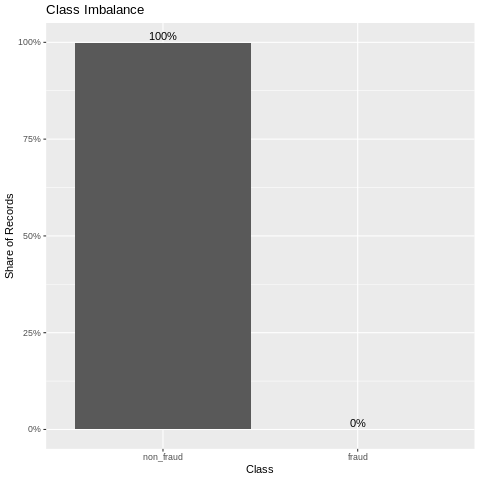

In [9]:
%%R
# ---- 2c: Class imbalance ----
class_dist <- raw %>% count(Class) %>% mutate(pct = n / sum(n))
ggplot(class_dist, aes(x = Class, y = pct, label = scales::percent(pct))) +
  geom_col() + geom_text(vjust = -0.3) +
  scale_y_continuous(labels = scales::percent_format(), limits = c(0,1)) +
  labs(title = 'Class Imbalance', x = 'Class', y = 'Share of Records')


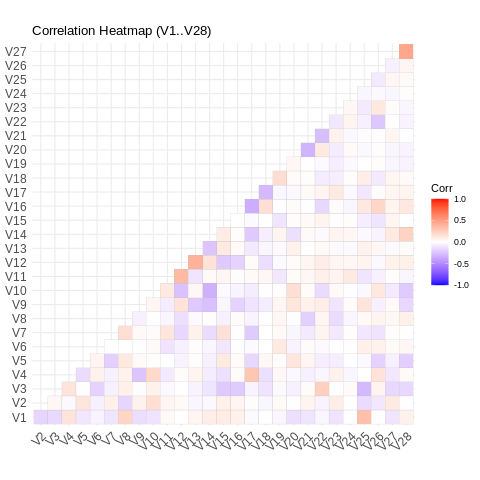

In [10]:

%%R
# ---- 2d: Correlation heatmap (V1..V28) ----
V_cols <- grep('^V[0-9]+$', names(raw), value = TRUE)
cor_mat <- cor(raw[, V_cols], use = 'pairwise.complete.obs')
ggcorrplot::ggcorrplot(cor_mat, lab = FALSE, type = 'lower', title = 'Correlation Heatmap (V1..V28)')


## Step 3 — Preprocessing
Check missing values, stratified split, imputation, normalization, and SMOTE (within training).

In [11]:
%%R
# ---- 3.1: Missing values ----
missing_summary <- tibble(feature = names(raw), n_missing = sapply(raw, function(x) sum(is.na(x))), pct_missing = sapply(raw, function(x) mean(is.na(x)))) %>% arrange(desc(pct_missing))
missing_summary


# A tibble: 31 × 3
   feature n_missing pct_missing
   <chr>       <int>       <dbl>
 1 Time            0           0
 2 V1              0           0
 3 V2              0           0
 4 V3              0           0
 5 V4              0           0
 6 V5              0           0
 7 V6              0           0
 8 V7              0           0
 9 V8              0           0
10 V9              0           0
# ℹ 21 more rows
# ℹ Use `print(n = ...)` to see more rows


In [12]:
%%R

# ---- 3.2: Stratified train/test split ----
set.seed(123)
split <- initial_split(raw, prop = 0.80, strata = Class)
train <- training(split)
test <- testing(split)
train %>% count(Class) %>% mutate(pct = n / sum(n))


# A tibble: 2 × 3
  Class         n      pct
  <fct>     <int>    <dbl>
1 non_fraud  3175 0.999   
2 fraud         2 0.000630


In [13]:
%%R
# ---- 3.3: Recipe (impute + mutate + normalize) ----
base_recipe <- recipe(Class ~ ., data = train) %>%
  step_impute_median(all_numeric_predictors()) %>%
  step_mutate(log_amount = log1p(Amount)) %>%
  step_normalize(all_numeric_predictors())
summary(base_recipe)


# A tibble: 31 × 4
   variable type      role      source  
   <chr>    <list>    <chr>     <chr>   
 1 Time     <chr [2]> predictor original
 2 V1       <chr [2]> predictor original
 3 V2       <chr [2]> predictor original
 4 V3       <chr [2]> predictor original
 5 V4       <chr [2]> predictor original
 6 V5       <chr [2]> predictor original
 7 V6       <chr [2]> predictor original
 8 V7       <chr [2]> predictor original
 9 V8       <chr [2]> predictor original
10 V9       <chr [2]> predictor original
# ℹ 21 more rows
# ℹ Use `print(n = ...)` to see more rows


In [14]:
%%R
# ---- 3.4: Prep & bake ----
prep_base <- prep(base_recipe, training = train)
train_prepped <- bake(prep_base, new_data = train)
test_prepped <- bake(prep_base, new_data = test)
glimpse(train_prepped)


Rows: 3,177
Columns: 32
$ Time       <dbl> -1.613855, -1.613855, -1.612871, -1.611886, -1.609918, -1.6…
$ V1         <dbl> -0.77678643, 1.13242198, -0.48233502, -0.62596453, 1.160705…
$ V2         <dbl> -0.33482795, -0.03754549, -0.43345508, 0.49888620, -0.14731…
$ V3         <dbl> 1.73098085, -0.69823419, 0.96901170, 0.71861883, -0.8223764…
$ V4         <dbl> 0.95139177, 0.29490310, -0.63084740, 0.26305274, 0.82747617…
$ V5         <dbl> -0.24029254, 0.09221292, 0.03350918, -0.29778265, 0.2022833…
$ V6         <dbl> 0.34305124, -0.08846288, 0.96473054, 0.05276065, 0.19279945…
$ V7         <dbl> 0.07723146, -0.21853305, 0.07538330, 0.40545250, -0.1501248…
$ V8         <dbl> 0.133296912, 0.122004834, 0.364796893, -0.173359806, 0.1187…
$ V9         <dbl> 0.33133304, -0.34217805, -1.57300740, 0.82509266, 0.4413779…
$ V10        <dbl> 0.148542899, -0.112067442, 0.001190035, 0.818124428, -0.043…
$ V11        <dbl> -0.68351285, 1.47105422, -0.35986654, -0.95353314, -1.54491…
$ V12        <db

In [15]:
%%R
# ---- 3.5: SMOTE recipe for resampling (do NOT apply to final test) ----
smote_recipe <- recipe(Class ~ ., data = train) %>%
  step_impute_median(all_numeric_predictors()) %>%
  step_mutate(log_amount = log1p(Amount)) %>%
  step_normalize(all_numeric_predictors()) %>%
  themis::step_smote(Class, over_ratio = 1)
summary(smote_recipe)


# A tibble: 31 × 4
   variable type      role      source  
   <chr>    <list>    <chr>     <chr>   
 1 Time     <chr [2]> predictor original
 2 V1       <chr [2]> predictor original
 3 V2       <chr [2]> predictor original
 4 V3       <chr [2]> predictor original
 5 V4       <chr [2]> predictor original
 6 V5       <chr [2]> predictor original
 7 V6       <chr [2]> predictor original
 8 V7       <chr [2]> predictor original
 9 V8       <chr [2]> predictor original
10 V9       <chr [2]> predictor original
# ℹ 21 more rows
# ℹ Use `print(n = ...)` to see more rows


In [38]:
# %%R
# # ---- 3.6: Demonstrate SMOTE effect (for understanding only) ----
# prep_smote <- prep(smote_recipe, training = train)
# train_smote_baked <- bake(prep_smote, new_data = train)
# train %>% count(Class) %>% mutate(pct = n/sum(n))
# train_smote_baked %>% count(Class) %>% mutate(pct = n/sum(n))


In [19]:
%%R
# ---- 3.7: Save preprocessed datasets (optional) ----
readr::write_csv(train_prepped, "train_preprocessed.csv")
readr::write_csv(test_prepped,  "test_preprocessed.csv")
# readr::write_csv(train_smote_baked, "train_smote_balanced.csv")


## Step 4 — Feature Engineering & Reduction
Create new features and apply PCA & UMAP for visualization and dimensionality reduction.

In [21]:
%%R
# ---- 4.1: Feature engineering (example features) ----
# Since the dataset lacks user IDs, we add derived features: log_amount (already added), hour from Time.
train <- train %>% mutate(hour = as.integer((Time %% 86400) / 3600))
test <- test %>% mutate(hour = as.integer((Time %% 86400) / 3600))

# Re-prep recipe to include hour
fe_recipe <- recipe(Class ~ ., data = train) %>%
  step_impute_median(all_numeric_predictors()) %>%
  step_mutate(log_amount = log1p(Amount)) %>%
  step_normalize(all_numeric_predictors())
prep_fe <- prep(fe_recipe, training = train)
train_fe <- bake(prep_fe, new_data = train)
test_fe  <- bake(prep_fe, new_data = test)
glimpse(train_fe)


Rows: 3,177
Columns: 33
$ Time       <dbl> -1.613855, -1.613855, -1.612871, -1.611886, -1.609918, -1.6…
$ V1         <dbl> -0.77678643, 1.13242198, -0.48233502, -0.62596453, 1.160705…
$ V2         <dbl> -0.33482795, -0.03754549, -0.43345508, 0.49888620, -0.14731…
$ V3         <dbl> 1.73098085, -0.69823419, 0.96901170, 0.71861883, -0.8223764…
$ V4         <dbl> 0.95139177, 0.29490310, -0.63084740, 0.26305274, 0.82747617…
$ V5         <dbl> -0.24029254, 0.09221292, 0.03350918, -0.29778265, 0.2022833…
$ V6         <dbl> 0.34305124, -0.08846288, 0.96473054, 0.05276065, 0.19279945…
$ V7         <dbl> 0.07723146, -0.21853305, 0.07538330, 0.40545250, -0.1501248…
$ V8         <dbl> 0.133296912, 0.122004834, 0.364796893, -0.173359806, 0.1187…
$ V9         <dbl> 0.33133304, -0.34217805, -1.57300740, 0.82509266, 0.4413779…
$ V10        <dbl> 0.148542899, -0.112067442, 0.001190035, 0.818124428, -0.043…
$ V11        <dbl> -0.68351285, 1.47105422, -0.35986654, -0.95353314, -1.54491…
$ V12        <db

In [22]:
%%R
# ---- 4.2: PCA (2 components) on numeric predictors ----
num_cols <- train_fe %>% select(where(is.numeric)) %>% names()
pca_res <- prcomp(train_fe %>% select(all_of(num_cols)), center = TRUE, scale. = TRUE)
# Project train and test into first 2 PCs
train_pca <- as.data.frame(pca_res$x[,1:2]) %>% setNames(c('PC1','PC2')) %>% bind_cols(Class = train_fe$Class)
test_pca  <- as.data.frame(predict(pca_res, newdata = test_fe %>% select(all_of(num_cols)))[,1:2]) %>% setNames(c('PC1','PC2')) %>% bind_cols(Class = test_fe$Class)
head(train_pca)


         PC1         PC2     Class
1 -0.8455079  1.52752669 non_fraud
2  0.1372559 -0.64135627 non_fraud
3 -1.2658501 -0.04229127 non_fraud
4 -0.6595114  1.81057493 non_fraud
5 -0.2493944 -0.32456209 non_fraud
6  1.7247624  3.32608154 non_fraud


In [23]:
%%R
# ---- 4.3: UMAP (2D) for visualization ----
set.seed(123)
umap_train <- uwot::umap(train_fe %>% select(all_of(num_cols)), n_neighbors = 15, min_dist = 0.1, n_components = 2)
umap_df <- as.data.frame(umap_train) %>% setNames(c('UMAP1','UMAP2')) %>% bind_cols(Class = train_fe$Class)
head(umap_df)


      UMAP1     UMAP2     Class
1  3.030481  2.423761 non_fraud
2 -2.390571 -2.810274 non_fraud
3 -2.740491  1.809009 non_fraud
4  2.762652  1.668012 non_fraud
5 -5.373471 -3.621411 non_fraud
6  1.684937  2.011769 non_fraud


## Step 5 — Second EDA (Post-Processing)
Visualize PCA and UMAP embeddings colored by Class and compute feature importance with Random Forest.

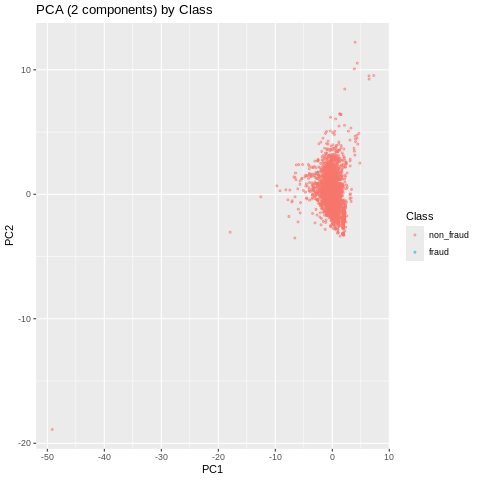

In [25]:
%%R
# ---- 5.1: PCA scatter ----
ggplot(train_pca, aes(x = PC1, y = PC2, color = Class)) + geom_point(alpha = 0.5, size = 0.8) + labs(title = 'PCA (2 components) by Class')


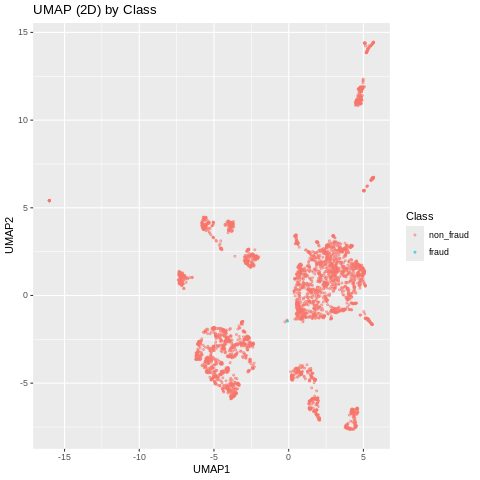

In [26]:
%%R
# ---- 5.2: UMAP scatter ----
ggplot(umap_df, aes(x = UMAP1, y = UMAP2, color = Class)) + geom_point(alpha = 0.5, size = 0.8) + labs(title = 'UMAP (2D) by Class')


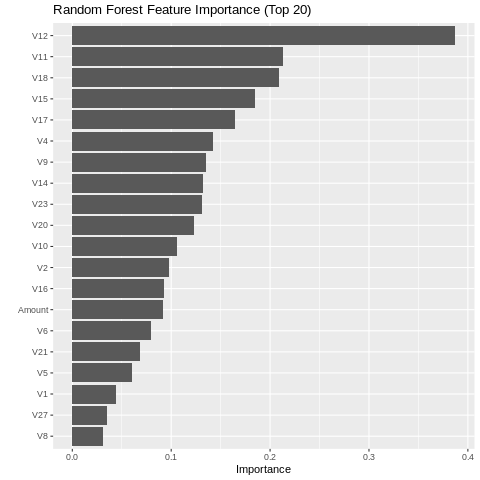

In [55]:
%%R
# ---- 5.3: Random Forest feature importance (train without SMOTE for clarity) ----
rf_imp_recipe <- recipe(Class ~ ., data = train) %>% step_impute_median(all_numeric_predictors()) %>% step_normalize(all_numeric_predictors())
rf_spec <- rand_forest(trees = 500) %>% set_mode('classification') %>% set_engine('ranger', importance = 'impurity')
rf_wf <- workflow() %>% add_model(rf_spec) %>% add_recipe(rf_imp_recipe)
rf_fit <- fit(rf_wf, data = train)

# Extract ranger object and VIP
ranger_obj <- extract_fit_parsnip(rf_fit)$fit
vip::vip(ranger_obj, num_features = 20) + ggtitle('Random Forest Feature Importance (Top 20)')


## Step 6 — Modeling
Train Logistic Regression, Decision Tree, and Random Forest using tidymodels and stratified CV. SMOTE is included inside the recipe for resampling.

In [28]:
%%R
# ---- 6.1: Model specifications ----
set.seed(123)
log_spec <- logistic_reg() %>% set_mode('classification') %>% set_engine('glm')
tree_spec <- decision_tree(cost_complexity = tune(), tree_depth = tune(), min_n = tune()) %>% set_mode('classification') %>% set_engine('rpart')
rf_spec <- rand_forest(trees = 500, mtry = tune(), min_n = tune()) %>% set_mode('classification') %>% set_engine('ranger')


In [29]:
%%R
# ---- 6.2: Workflows and resampling ----
# Use smote_recipe so SMOTE happens inside CV folds
wf_log <- workflow() %>% add_model(log_spec) %>% add_recipe(smote_recipe)
wf_tree <- workflow() %>% add_model(tree_spec) %>% add_recipe(smote_recipe)
wf_rf   <- workflow() %>% add_model(rf_spec) %>% add_recipe(smote_recipe)

# 5-fold stratified CV
set.seed(123)
cv_splits <- vfold_cv(train, v = 5, strata = Class)


In [31]:
# %%R
# # ---- 6.3: Tuning tree and rf quickly (small grid for demonstration) ----
# tree_params <- parameters(tree_spec) %>% update(tree_depth = tree_depth(range = c(1L, 15L)))
# rf_params <- parameters(rf_spec)

# grid_tree <- grid_regular(tree_params, levels = c(tree_depth = 3, min_n = 3, cost_complexity = 3))
# grid_rf <- grid_random(rf_params, size = 6)

# ctrl <- control_grid(save_pred = TRUE)

# # Tuning RF as example (may take time)
# set.seed(123)
# rf_tune_res <- tune_grid(wf_rf, resamples = cv_splits, grid = grid_rf, control = ctrl, metrics = metric_set(roc_auc, pr_auc))
# rf_tune_res %>% collect_metrics()


In [58]:
%%R
raw

# A tibble: 3,972 × 31
    Time     V1      V2      V3     V4      V5      V6       V7      V8     V9
   <dbl>  <dbl>   <dbl>   <dbl>  <dbl>   <dbl>   <dbl>    <dbl>   <dbl>  <dbl>
 1     0 -1.36  -0.0728  2.54    1.38  -0.338   0.462   0.240    0.0987  0.364
 2     0  1.19   0.266   0.166   0.448  0.0600 -0.0824 -0.0788   0.0851 -0.255
 3     1 -1.36  -1.34    1.77    0.380 -0.503   1.80    0.791    0.248  -1.51 
 4     1 -0.966 -0.185   1.79   -0.863 -0.0103  1.25    0.238    0.377  -1.39 
 5     2 -1.16   0.878   1.55    0.403 -0.407   0.0959  0.593   -0.271   0.818
 6     2 -0.426  0.961   1.14   -0.168  0.421  -0.0297  0.476    0.260  -0.569
 7     4  1.23   0.141   0.0454  1.20   0.192   0.273  -0.00516  0.0812  0.465
 8     7 -0.644  1.42    1.07   -0.492  0.949   0.428   1.12    -3.81    0.615
 9     7 -0.894  0.286  -0.113  -0.272  2.67    3.72    0.370    0.851  -0.392
10     9 -0.338  1.12    1.04   -0.222  0.499  -0.247   0.652    0.0695 -0.737
# ℹ 3,962 more rows
# ℹ 21 mo

In [59]:
%%R
data <- raw

In [61]:
%%R
# Extract parameter sets
tree_params <- parameters(tree_spec) %>%
  update(tree_depth = tree_depth(range = c(1L, 15L)))

rf_params <- parameters(rf_spec)

# Create grids
grid_tree <- grid_regular(tree_params, levels = 3)  # 3 levels for each param
grid_rf   <- grid_random(rf_params, size = 6)


Error in (function (cond)  : 
  error in evaluating the argument 'object' in selecting a method for function 'update': <parameters> objects cannot be created from a <decision_tree> object.


RInterpreterError: Failed to parse and evaluate line '# Extract parameter sets\ntree_params <- parameters(tree_spec) %>% \n  update(tree_depth = tree_depth(range = c(1L, 15L)))\n\nrf_params <- parameters(rf_spec)\n\n# Create grids\ngrid_tree <- grid_regular(tree_params, levels = 3)  # 3 levels for each param\ngrid_rf   <- grid_random(rf_params, size = 6)\n'.
R error message: "Error in (function (cond)  : \n  error in evaluating the argument 'object' in selecting a method for function 'update': <parameters> objects cannot be created from a <decision_tree> object."

In [ ]:
# ---- 6.4: Fit final models on full train (using tuned RF params if available) ----
best_rf <- rf_tune_res %>% select_best('roc_auc')

rf_final_spec <- finalize_model(rf_spec, best_rf)
rf_final_wf <- workflow() %>% add_model(rf_final_spec) %>% add_recipe(smote_recipe)

# Fit models
log_fit <- fit(wf_log, data = train)
tree_fit <- fit(wf_tree, data = train)
rf_fit_final <- fit(rf_final_wf, data = train)

models_list <- list(log = log_fit, tree = tree_fit, rf = rf_fit_final)
models_list


## Step 7 — Evaluation on Held-out Test Set
Compute predictions, confusion matrices, ROC & PR curves for each final model.

In [ ]:
# ---- 7.1: Helper to get predictions and metrics ----
eval_on_test <- function(fit_wf, test_data) {
  probs <- predict(fit_wf, test_data, type = 'prob')
  classes <- predict(fit_wf, test_data)
  out <- bind_cols(test_data %>% select(Class), probs, classes)
  cm <- conf_mat(out, truth = Class, estimate = .pred_class)
  roc_df <- roc_curve(out, truth = Class, .pred_fraud)
  pr_df  <- pr_curve(out, truth = Class, .pred_fraud)
  metrics <- metric_set(accuracy, precision, recall, f_meas, roc_auc, pr_auc)
  met <- metrics(out, truth = Class, estimate = .pred_class, .pred_fraud)
  list(conf_mat = cm, roc = roc_df, pr = pr_df, metrics = met, preds = out)
}

# Evaluate each model
res_log <- eval_on_test(log_fit, test)
res_tree <- eval_on_test(tree_fit, test)
res_rf   <- eval_on_test(rf_fit_final, test)

# Print logistic results example
res_log$conf_mat
res_log$metrics


In [ ]:
# ---- 7.2: Plot ROC & PR curves ----
plot_roc <- function(df, title) {
  ggplot(df, aes(x = 1 - specificity, y = sensitivity)) + geom_path() + geom_abline(linetype = 3) + labs(title = title)
}
plot_pr <- function(df, title) {
  ggplot(df, aes(x = recall, y = precision)) + geom_path() + labs(title = title)
}

print(plot_roc(res_log$roc, 'ROC - Logistic Regression'))
print(plot_pr(res_log$pr, 'PR - Logistic Regression'))
print(plot_roc(res_tree$roc, 'ROC - Decision Tree'))
print(plot_pr(res_tree$pr, 'PR - Decision Tree'))
print(plot_roc(res_rf$roc, 'ROC - Random Forest'))
print(plot_pr(res_rf$pr, 'PR - Random Forest'))


## Step 8 — Interpretation & Ethical Notes
- In fraud detection, recall (true positive rate) is often prioritized because false negatives (missed fraud) are costly. Balance with precision to limit false alarms.
- Consider human-in-the-loop verification for flagged transactions.
- Monitor model drift and fairness over time.

In [ ]:
# ---- 8.1: Summarize precision/recall/F1 from confusion matrices ----
f1_from_cm <- function(cm) {
  m <- as.matrix(cm$table)
  tp <- m['fraud','fraud']
  fp <- m['non_fraud','fraud']
  fn <- m['fraud','non_fraud']
  precision <- ifelse(tp+fp == 0, 0, tp/(tp+fp))
  recall <- ifelse(tp+fn == 0, 0, tp/(tp+fn))
  f1 <- ifelse(precision+recall == 0, 0, 2*precision*recall/(precision+recall))
  tibble(precision = precision, recall = recall, f1 = f1)
}

summary_tbl <- bind_rows(
  f1_from_cm(res_log$conf_mat) %>% mutate(model = 'Logistic Regression'),
  f1_from_cm(res_tree$conf_mat) %>% mutate(model = 'Decision Tree'),
  f1_from_cm(res_rf$conf_mat) %>% mutate(model = 'Random Forest')
) %>% select(model, precision, recall, f1) %>% arrange(desc(f1))

summary_tbl
